# Lecture 8: Market Efficiency, Random Walks, Anomalies, and Event Studies

## Investment Analysis

This lecture studies the Efficient Market Hypothesis, or EMH. The central question is:

> How quickly and accurately do market prices incorporate information?

The lecture covers random walks, weak-form, semi-strong-form, and strong-form efficiency; technical and fundamental analysis; active versus passive management; event-study methods; anomalies; the joint hypothesis problem; and the performance of analysts and mutual fund managers.

The notebook also uses the uploaded JKP factor data to examine real factor portfolios associated with anomalies.

> **Update note.** This cohesive-flow version uses the uploaded full JKP file
> `[usa]_[all_factors]_[monthly]_[vw_cap].csv` for the real anomaly and fundamental-characteristic analysis. It keeps the expanded technical-analysis visuals, moves the JKP fundamental-characteristics material next to the Fundamental Analysis discussion, and moves the mutual-fund performance simulations next to the Analysts and Mutual Fund Managers discussion.

# 1. Learning Objectives

By the end of this lecture, students should be able to define the three forms of EMH, explain why efficient prices often look like random walks, distinguish technical from fundamental analysis, conduct weak-form tests, run an event study, interpret anomalies, explain the joint hypothesis problem, and discuss evidence on analysts and mutual fund managers.

# 2. Setup: Libraries and JKP Factor Data

The notebook uses simulated data for clean demonstrations and the uploaded JKP all-factors CSV for real anomaly and fundamental-characteristic evidence.

The uploaded file is:

```text
[usa]_[all_factors]_[monthly]_[vw_cap].csv
```

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(2027)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

DATA_FILE = Path('/mnt/data/[usa]_[all_factors]_[monthly]_[vw_cap].csv')
if not DATA_FILE.exists():
    DATA_FILE = Path('[usa]_[all_factors]_[monthly]_[vw_cap].csv')
print('JKP file:', DATA_FILE)
print('Exists:', DATA_FILE.exists())

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-4vn69vow because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Matplotlib is building the font cache; this may take a moment.


JKP file: /mnt/data/[usa]_[all_factors]_[monthly]_[vw_cap].csv
Exists: True


In [2]:
if DATA_FILE.exists():
    jkp_long = pd.read_csv(DATA_FILE, encoding='utf-8-sig')
    jkp_long['date'] = pd.to_datetime(jkp_long['date'])
    jkp_factors = (jkp_long
        .pivot_table(index='date', columns='name', values='ret', aggfunc='mean')
        .sort_index())
    jkp_factors.index.name = 'Date'
else:
    jkp_long = None
    jkp_factors = pd.DataFrame()

display(jkp_factors.head())
print('JKP factor matrix shape:', jkp_factors.shape)
print('Factor names:', list(jkp_factors.columns))

name,age,aliq_at,aliq_mat,ami_126d,at_be,at_gr1,at_me,at_turnover,be_gr1a,be_me,beta_60m,beta_dimson_21d,betabab_1260d,betadown_252d,bev_mev,bidaskhl_21d,capex_abn,capx_gr1,capx_gr2,capx_gr3,cash_at,chcsho_12m,coa_gr1a,col_gr1a,cop_at,cop_atl1,corr_1260d,coskew_21d,cowc_gr1a,dbnetis_at,debt_gr3,debt_me,dgp_dsale,div12m_me,dolvol_126d,dolvol_var_126d,dsale_dinv,dsale_drec,dsale_dsga,earnings_variability,...,ret_12_1,ret_12_7,ret_1_0,ret_3_1,ret_60_12,ret_6_1,ret_9_1,rmax1_21d,rmax5_21d,rmax5_rvol_21d,rskew_21d,rvol_21d,sale_bev,sale_emp_gr1,sale_gr1,sale_gr3,sale_me,saleq_gr1,saleq_su,seas_11_15an,seas_11_15na,seas_16_20an,seas_16_20na,seas_1_1an,seas_1_1na,seas_2_5an,seas_2_5na,seas_6_10an,seas_6_10na,sti_gr1a,taccruals_at,taccruals_ni,tangibility,tax_gr1a,turnover_126d,turnover_var_126d,z_score,zero_trades_126d,zero_trades_21d,zero_trades_252d
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1926-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1926-02-28,-0.0661,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0185,NaN,NaN,NaN,-0.0312,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.0026,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,-0.0184,NaN,NaN,NaN,NaN,0.0360,0.0379,NaN,0.0108,0.0423,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0204,NaN
1926-03-31,-0.0920,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0581,NaN,NaN,NaN,-0.0630,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0041,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,-0.0442,NaN,NaN,NaN,NaN,0.0373,0.0386,NaN,-0.0257,0.0604,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0222,NaN
1926-04-30,-0.0183,NaN,NaN,-0.0036,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.0077,NaN,NaN,NaN,-0.0106,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0088,NaN,NaN,NaN,NaN,NaN,NaN,-0.0089,0.0076,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0002,-0.0096,NaN,NaN,NaN,-0.0089,-0.0044,NaN,0.0040,-0.0022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.0024,0.0055,NaN,-0.0034,-0.0045,NaN
1926-05-31,-0.0096,NaN,NaN,0.0055,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0113,NaN,NaN,NaN,-0.0139,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0036,NaN,NaN,NaN,NaN,NaN,NaN,0.0060,0.0034,NaN,NaN,NaN,NaN,...,NaN,NaN,-0.0224,0.0200,NaN,NaN,NaN,-0.0042,0.0039,NaN,-0.0078,0.0062,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0069,0.0006,NaN,-0.0014,-0.0038,NaN


JKP factor matrix shape: (1200, 153)
Factor names: ['age', 'aliq_at', 'aliq_mat', 'ami_126d', 'at_be', 'at_gr1', 'at_me', 'at_turnover', 'be_gr1a', 'be_me', 'beta_60m', 'beta_dimson_21d', 'betabab_1260d', 'betadown_252d', 'bev_mev', 'bidaskhl_21d', 'capex_abn', 'capx_gr1', 'capx_gr2', 'capx_gr3', 'cash_at', 'chcsho_12m', 'coa_gr1a', 'col_gr1a', 'cop_at', 'cop_atl1', 'corr_1260d', 'coskew_21d', 'cowc_gr1a', 'dbnetis_at', 'debt_gr3', 'debt_me', 'dgp_dsale', 'div12m_me', 'dolvol_126d', 'dolvol_var_126d', 'dsale_dinv', 'dsale_drec', 'dsale_dsga', 'earnings_variability', 'ebit_bev', 'ebit_sale', 'ebitda_mev', 'emp_gr1', 'eq_dur', 'eqnetis_at', 'eqnpo_12m', 'eqnpo_me', 'eqpo_me', 'f_score', 'fcf_me', 'fnl_gr1a', 'gp_at', 'gp_atl1', 'inv_gr1', 'inv_gr1a', 'iskew_capm_21d', 'iskew_ff3_21d', 'iskew_hxz4_21d', 'ival_me', 'ivol_capm_21d', 'ivol_capm_252d', 'ivol_ff3_21d', 'ivol_hxz4_21d', 'kz_index', 'lnoa_gr1a', 'lti_gr1a', 'market_equity', 'mispricing_mgmt', 'mispricing_perf', 'ncoa_gr1a', 'nco

In [3]:
# Common helper functions for factor/anomaly analysis.

def annualized_summary(factors, periods_per_year=12):
    out = pd.DataFrame(index=factors.columns)
    out["Mean Ann. Return"] = factors.mean() * periods_per_year
    out["Ann. Volatility"] = factors.std(ddof=1) * np.sqrt(periods_per_year)
    out["Sharpe Ratio"] = out["Mean Ann. Return"] / out["Ann. Volatility"]
    out["Skewness"] = factors.skew()
    out["Excess Kurtosis"] = factors.kurtosis()
    out["Worst Month"] = factors.min()
    out["Best Month"] = factors.max()
    out["Observations"] = factors.count()
    return out.sort_values("Sharpe Ratio", ascending=False)

def drawdown_from_returns(r):
    wealth = (1 + r.fillna(0)).cumprod()
    peak = wealth.cummax()
    return wealth / peak - 1

# 3. What Is an Efficient Market?

A market is informationally efficient if prices incorporate information quickly and correctly. Efficiency does not mean prices are always perfect. It means that obvious profit opportunities based on available information should be difficult to exploit after costs, risk, and competition.

Market efficiency is a competitive equilibrium idea. If many investors search for mispriced securities, their trading tends to push prices toward values that reflect available information.

# 4. Why Efficiency Matters for Resource Allocation

Financial markets help allocate capital. If prices reflect expected cash flows and risk, high-value projects receive lower costs of capital and low-value projects receive less funding. If prices are badly distorted, capital can be misallocated: overpriced firms may overinvest, underpriced firms may underinvest, and bubbles can finance wasteful projects.

# 5. Weak, Semi-Strong, and Strong Forms

## Weak-form efficiency
Prices reflect all information contained in past prices and trading data. Pure chart rules, past-return rules, and trading-volume rules should not reliably earn abnormal returns after costs.

## Semi-strong-form efficiency
Prices reflect all publicly available information, including earnings, accounting data, macro data, and news.

## Strong-form efficiency
Prices reflect all public and private information. This is the strongest and least plausible form; insider trading evidence is usually treated as evidence against literal strong-form efficiency.

# 6. Random Walks and Efficient Prices

A random walk in log price is:

$$
p_{t+1}=p_t+\mu+\epsilon_{t+1},
$$

where:

$$
\mathbb{E}_t[\epsilon_{t+1}]=0.
$$

Returns are:

$$
r_{t+1}=p_{t+1}-p_t=\mu+\epsilon_{t+1}.
$$

If news is unpredictable and expected returns are stable, returns should be difficult to forecast from past returns.

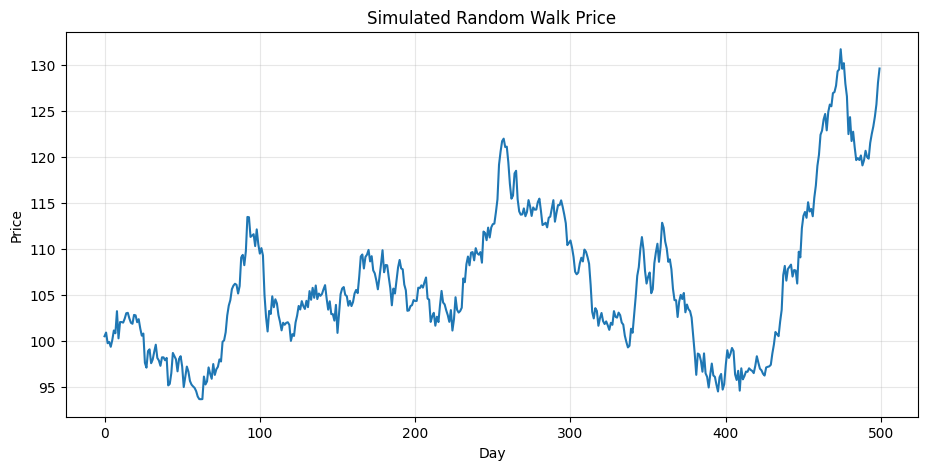

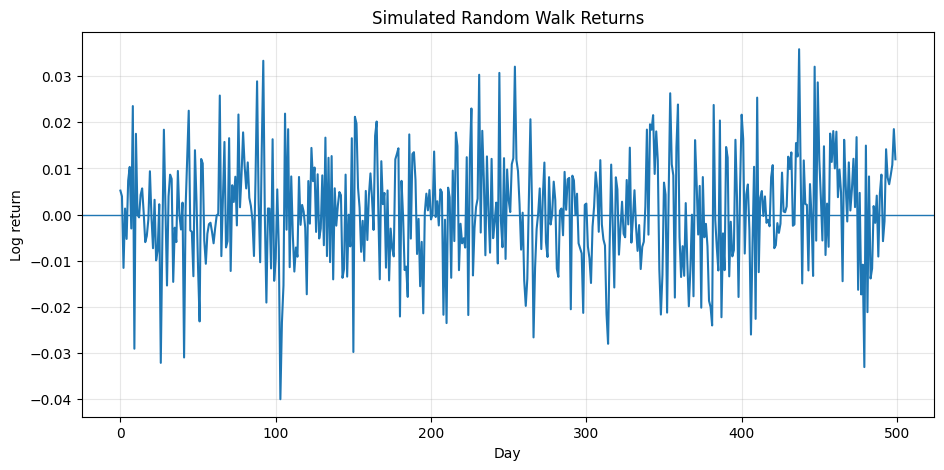

In [4]:
T=500
mu_daily=0.0003
sigma_daily=0.012
log_returns=mu_daily+np.random.normal(0,sigma_daily,T)
price=np.exp(np.log(100)+np.cumsum(log_returns))
rw=pd.DataFrame({'Log Return':log_returns,'Price':price})

plt.figure(figsize=(11,5))
plt.plot(rw['Price'])
plt.xlabel('Day'); plt.ylabel('Price')
plt.title('Simulated Random Walk Price')
plt.grid(True, alpha=0.3); plt.show()

plt.figure(figsize=(11,5))
plt.plot(rw['Log Return'])
plt.axhline(0, linewidth=1)
plt.xlabel('Day'); plt.ylabel('Log return')
plt.title('Simulated Random Walk Returns')
plt.grid(True, alpha=0.3); plt.show()

# 7. Weak-Form Tests: Serial Correlation

A basic weak-form test asks whether returns are serially correlated. The lag-$k$ autocorrelation is:

$$
\rho_k=\frac{\operatorname{Cov}(R_t,R_{t-k})}{\operatorname{Var}(R_t)}.
$$

Positive autocorrelation may indicate momentum or delayed reaction. Negative autocorrelation may indicate reversal or overreaction. But autocorrelation can also reflect time-varying expected returns, microstructure effects, or stale prices.

,Lag,Autocorrelation
0,1,0.0061
1,2,0.0583
2,3,0.0200
3,4,0.0661
4,5,0.0359
5,6,-0.0628
6,7,-0.0860
7,8,0.0032
8,9,0.0573
9,10,0.0556


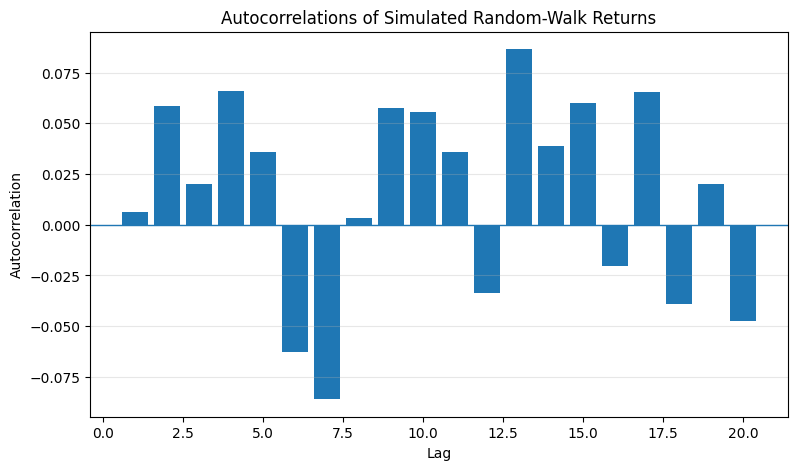

In [5]:
def autocorr_table(x, max_lag=12):
    x=pd.Series(x).dropna()
    return pd.DataFrame({'Lag':range(1,max_lag+1),
                         'Autocorrelation':[x.autocorr(lag) for lag in range(1,max_lag+1)]})
rw_ac=autocorr_table(rw['Log Return'],20)
display(rw_ac)
plt.figure(figsize=(9,5))
plt.bar(rw_ac['Lag'], rw_ac['Autocorrelation'])
plt.axhline(0, linewidth=1)
plt.xlabel('Lag'); plt.ylabel('Autocorrelation')
plt.title('Autocorrelations of Simulated Random-Walk Returns')
plt.grid(True, axis='y', alpha=0.3); plt.show()

# 8. Technical Analysis

Technical analysis attempts to forecast prices using market-generated data. Examples include support levels, resistance levels, moving-average crossovers, relative strength, trend-following, volume indicators, and chart patterns. Weak-form efficiency says purely technical rules should not reliably earn abnormal returns after costs and risk.

Support and resistance may still matter if they reflect liquidity clustering, stop-loss orders, option hedging, institutional rules, or psychological reference points. Moving-average rules may reduce drawdowns in some samples but can also miss rebounds and create whipsaw trades.

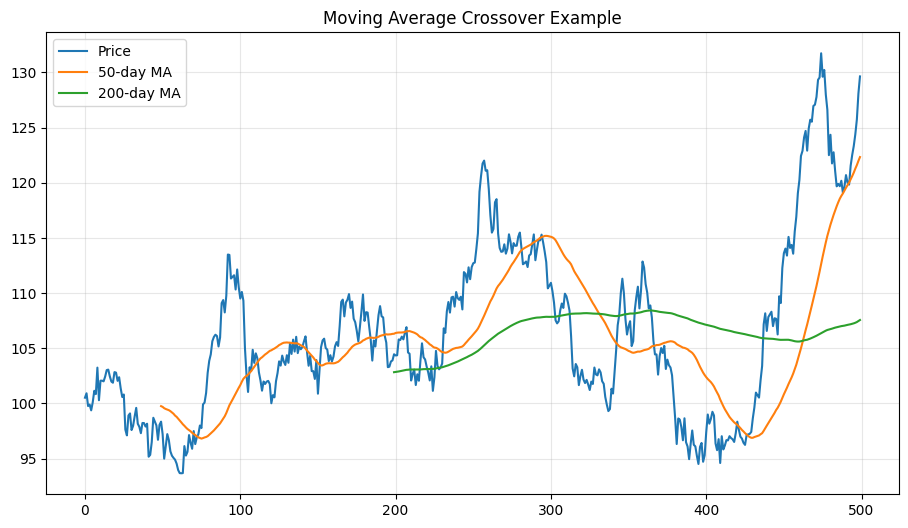

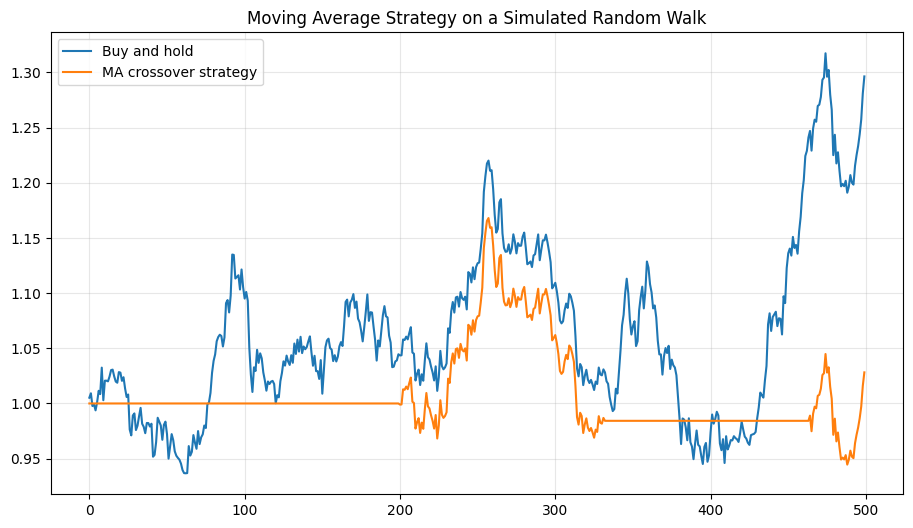

In [6]:
rw['MA_50']=rw['Price'].rolling(50).mean()
rw['MA_200']=rw['Price'].rolling(200).mean()
rw['Signal']=(rw['MA_50']>rw['MA_200']).astype(float)
rw['Strategy Return']=rw['Signal'].shift(1).fillna(0)*rw['Log Return']
rw['BuyHold Wealth']=np.exp(rw['Log Return'].cumsum())
rw['MA Strategy Wealth']=np.exp(rw['Strategy Return'].cumsum())

plt.figure(figsize=(11,6))
plt.plot(rw['Price'], label='Price')
plt.plot(rw['MA_50'], label='50-day MA')
plt.plot(rw['MA_200'], label='200-day MA')
plt.title('Moving Average Crossover Example')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

plt.figure(figsize=(11,6))
plt.plot(rw['BuyHold Wealth'], label='Buy and hold')
plt.plot(rw['MA Strategy Wealth'], label='MA crossover strategy')
plt.title('Moving Average Strategy on a Simulated Random Walk')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

## 8.1 Visual Example: Support and Resistance Levels

A **support level** is a price zone where declines tend to slow because buyers emerge.

A **resistance level** is a price zone where advances tend to slow because sellers emerge.

In practice, these levels are not physical laws. They are heuristics. Still, they are widely used by traders and are useful for teaching how technical analysts think about price charts.

The next visual creates a stylized price path with repeated interaction around a lower support region and an upper resistance region.

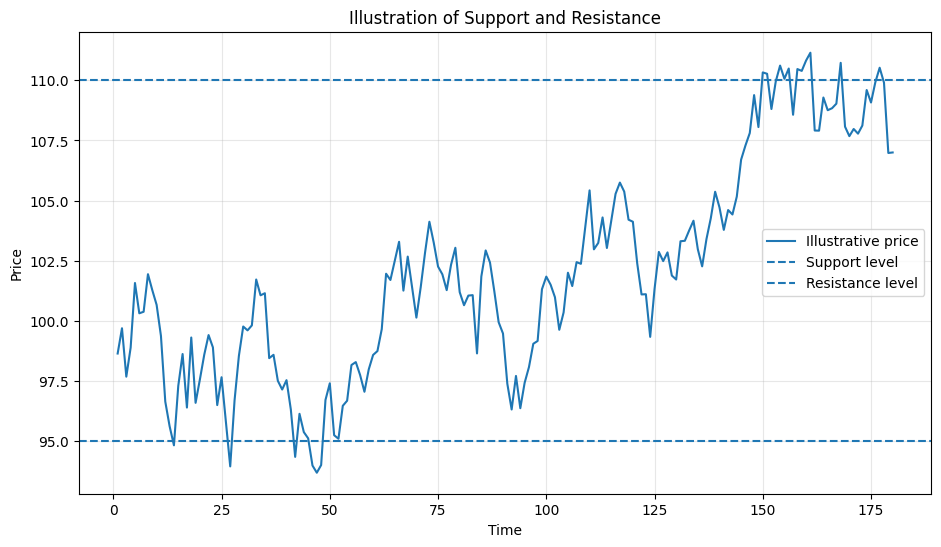

In [7]:
# Stylized support and resistance illustration

np.random.seed(2028)

n = 180
support_level = 95
resistance_level = 110

price_path = []
p = 100.0

for t in range(n):
    drift = 0.04 * np.sin(t / 8)
    shock = np.random.normal(0, 1.2)
    p = p + drift + shock

    # Nudge the series so that it repeatedly interacts with support and resistance.
    if p < support_level - 2:
        p = support_level + abs(np.random.normal(0, 1.5))
    if p > resistance_level + 2:
        p = resistance_level - abs(np.random.normal(0, 1.5))
    price_path.append(p)

tech_price = pd.Series(price_path, index=pd.RangeIndex(start=1, stop=n+1, step=1), name="Price")

plt.figure(figsize=(11, 6))
plt.plot(tech_price.index, tech_price.values, label="Illustrative price")
plt.axhline(support_level, linestyle="--", label="Support level")
plt.axhline(resistance_level, linestyle="--", label="Resistance level")
plt.xlabel("Time")
plt.ylabel("Price")
plt.title("Illustration of Support and Resistance")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Technical analysts often interpret repeated rebounds near support as a sign of buying interest and repeated failures near resistance as a sign of selling pressure.

A breakout above resistance or below support is often interpreted as new information or a change in market sentiment.

## 8.2 Relative Strength Index (RSI)

The **Relative Strength Index**, or RSI, is a momentum oscillator.

For a lookback window of \(n\) periods:

1. Compute average gains and average losses.
2. Form the relative strength:

$$
RS_t = \frac{\text{Average Gain}_t}{\text{Average Loss}_t}.
$$

3. Convert to RSI:

$$
RSI_t = 100 - \frac{100}{1 + RS_t}.
$$

Common conventions are:

- RSI above 70: potentially overbought,
- RSI below 30: potentially oversold.

These are not rigid laws. They are heuristic thresholds.

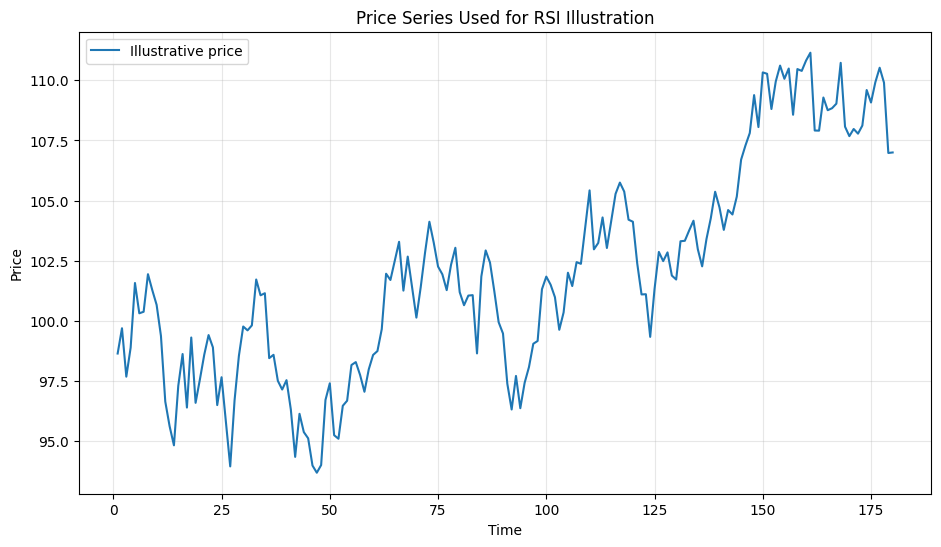

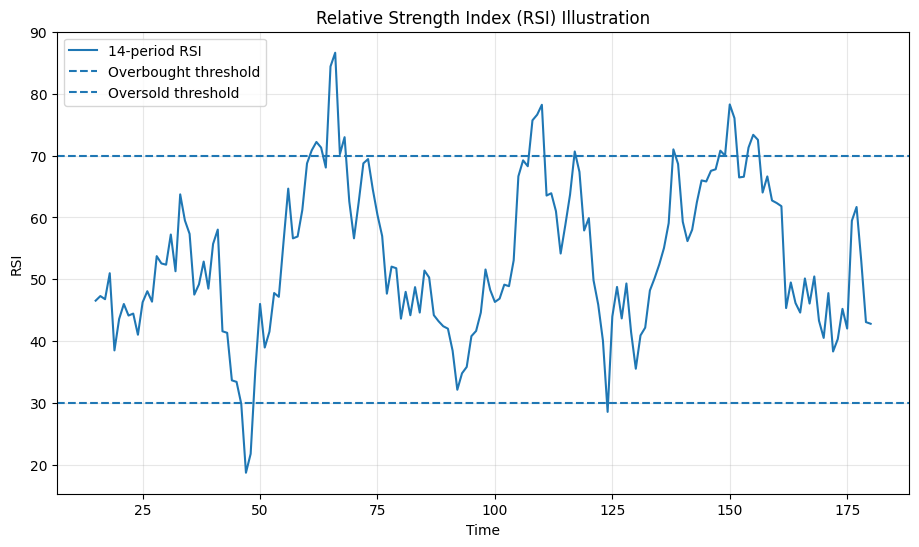

In [8]:
# Compute RSI on the illustrative price series

def compute_rsi(price, window=14):
    delta = price.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(window).mean()
    avg_loss = loss.rolling(window).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

rsi_14 = compute_rsi(tech_price, window=14)

plt.figure(figsize=(11, 6))
plt.plot(tech_price.index, tech_price.values, label="Illustrative price")
plt.xlabel("Time")
plt.ylabel("Price")
plt.title("Price Series Used for RSI Illustration")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(11, 6))
plt.plot(rsi_14.index, rsi_14.values, label="14-period RSI")
plt.axhline(70, linestyle="--", label="Overbought threshold")
plt.axhline(30, linestyle="--", label="Oversold threshold")
plt.xlabel("Time")
plt.ylabel("RSI")
plt.title("Relative Strength Index (RSI) Illustration")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

RSI tries to summarize the balance of recent gains and losses.

A high RSI means recent gains have dominated recent losses.

A low RSI means recent losses have dominated recent gains.

Like other technical indicators, RSI should not be treated as mechanically reliable. It is better understood as a compact description of recent price momentum.

## 8.3 Moving Averages, Trend Following, and Visual Signals

The moving-average crossover rule introduced earlier is a trend-following tool. Another useful visual is to place the signal directly on the chart.

When the short moving average rises above the long moving average, a technical analyst may call this a bullish signal. When it falls below, it may be interpreted as bearish.

The next figure overlays the signal regions on the price chart.

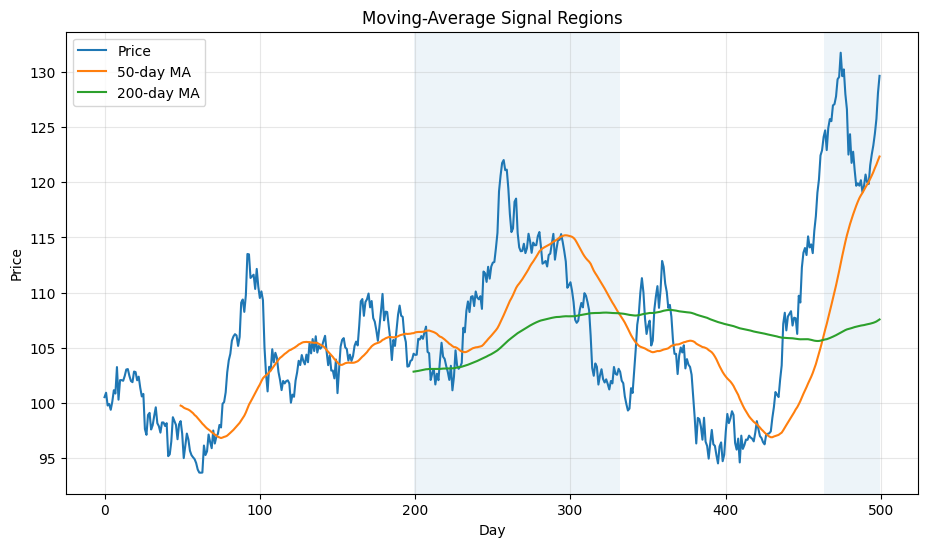

In [9]:
# Overlay moving-average signal on the simulated random walk price from above

rw["Signal"] = (rw["MA_50"] > rw["MA_200"]).astype(float)

plt.figure(figsize=(11, 6))
plt.plot(rw["Price"], label="Price")
plt.plot(rw["MA_50"], label="50-day MA")
plt.plot(rw["MA_200"], label="200-day MA")

# Shade periods when the strategy is "in the market"
signal_on = rw["Signal"].fillna(0).values
xvals = np.arange(len(rw))
for i in range(len(rw) - 1):
    if signal_on[i] == 1:
        plt.axvspan(i, i + 1, alpha=0.08)

plt.xlabel("Day")
plt.ylabel("Price")
plt.title("Moving-Average Signal Regions")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 8.4 Relative Strength as Cross-Sectional Ranking

A **relative strength** approach ranks securities by recent past performance and then tilts toward recent winners.

The next toy example illustrates the idea with several simulated assets. The goal is not realism but visualization of the ranking procedure.

,12-Month Relative Strength
Asset_2,0.0261
Asset_5,-0.0650
Asset_3,-0.0835
Asset_1,-0.1226
Asset_4,-0.2051


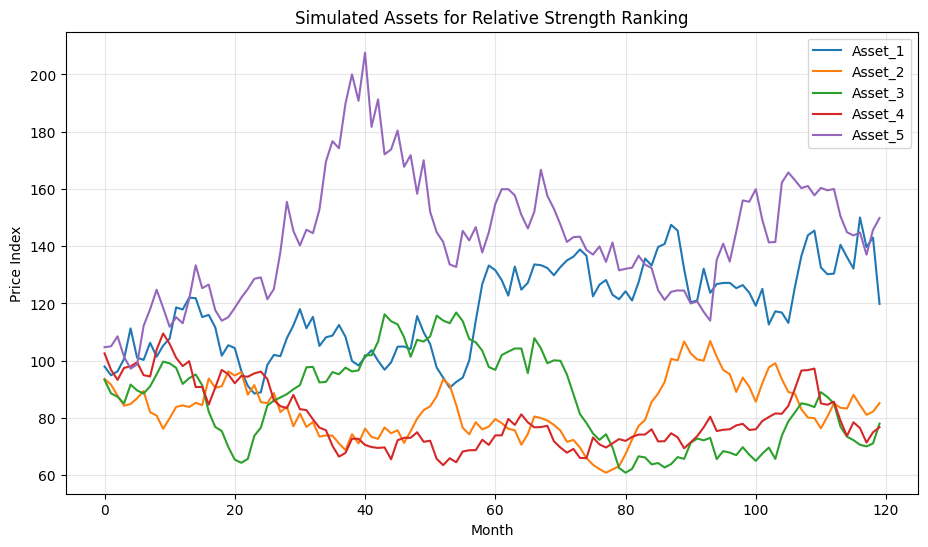

In [10]:
# Toy relative strength illustration with simulated assets

np.random.seed(2029)
T_rs = 120
assets = pd.DataFrame({
    f"Asset_{i}": 100 * np.exp(np.cumsum(np.random.normal(0.004/12, 0.05, T_rs)))
    for i in range(1, 6)
})

lookback = 12
relative_strength = assets.pct_change(lookback)

last_rs = relative_strength.iloc[-1].sort_values(ascending=False)
display(last_rs.to_frame("12-Month Relative Strength"))

plt.figure(figsize=(11, 6))
for col in assets.columns:
    plt.plot(assets.index, assets[col], label=col)
plt.xlabel("Month")
plt.ylabel("Price Index")
plt.title("Simulated Assets for Relative Strength Ranking")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In a relative-strength strategy, the analyst would often overweight the recent winners and underweight the recent losers.

This is closely related to cross-sectional momentum.

Weak-form efficiency says such rules should not generate persistent abnormal returns after costs unless there is a deeper economic or behavioral reason the effect survives.

# 9. Weak-Form Anomalies

Weak-form efficiency is challenged by evidence that past returns sometimes predict future returns. Momentum suggests underreaction or slow diffusion of information. Short-term reversal may reflect liquidity provision or bid-ask bounce. Long-horizon reversal may reflect overreaction, although risk-based explanations are possible. Broad market predictability from valuation ratios, term spreads, default spreads, or inflation may reflect time-varying risk premia rather than inefficiency.

,Factor,Lag 1 Autocorrelation,Lag 3 Autocorrelation,Lag 12 Autocorrelation
117,ret_60_12,0.2286,-0.0355,0.0287
91,ocf_at,0.2078,-0.0972,0.0032
29,dbnetis_at,0.2070,0.0782,0.0790
40,ebit_bev,0.2012,-0.0995,-0.0117
0,age,0.1946,-0.0646,-0.0756
...,...,...,...,...
132,seas_11_15an,-0.0445,0.0008,0.0061
151,zero_trades_21d,-0.0456,-0.0836,-0.0650
122,rmax5_rvol_21d,-0.0500,-0.0193,-0.0772
123,rskew_21d,-0.0615,-0.0349,-0.0349


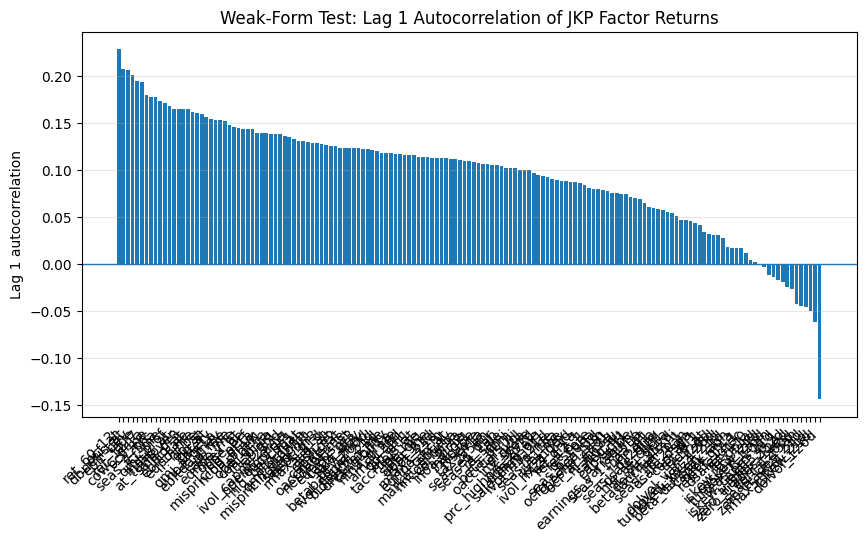

In [11]:
if not jkp_factors.empty:
    ac_rows=[]
    for col in jkp_factors.columns:
        x=jkp_factors[col].dropna()
        ac_rows.append({'Factor':col, 'Lag 1 Autocorrelation':x.autocorr(1), 'Lag 3 Autocorrelation':x.autocorr(3), 'Lag 12 Autocorrelation':x.autocorr(12)})
    ac_df=pd.DataFrame(ac_rows).sort_values('Lag 1 Autocorrelation', ascending=False)
    display(ac_df)
    plt.figure(figsize=(10,5))
    plt.bar(ac_df['Factor'], ac_df['Lag 1 Autocorrelation'])
    plt.axhline(0, linewidth=1)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Lag 1 autocorrelation')
    plt.title('Weak-Form Test: Lag 1 Autocorrelation of JKP Factor Returns')
    plt.grid(True, axis='y', alpha=0.3); plt.show()

# 10. Fundamental Analysis

Fundamental analysis estimates security value from earnings, cash flows, margins, book value, growth, leverage, investment, profitability, accruals, competitive position, and industry structure. Semi-strong efficiency says public fundamental information should already be incorporated into prices. Fundamental analysis can still add value if the analyst interprets information better, forecasts future information better, bears risks others avoid, exploits limits to arbitrage, trades cheaply, or studies neglected securities.

## 10.1 Fundamental Characteristics in the JKP Factor Data

Many empirical anomalies are based on fundamental firm characteristics rather than past prices.

Examples include:

- value,
- profitability,
- investment,
- accruals,
- leverage,
- quality,
- payout,
- growth,
- size,
- low risk.

The uploaded JKP factor file is useful here because it contains factor portfolios built from broad firm characteristics.

This lets students connect fundamental analysis to factor investing:

> A fundamental signal becomes a factor when firms are sorted into portfolios according to that characteristic and the return spread is tracked over time.

In [12]:
# Inspect the JKP factor names and classify them into broad teaching categories.
# These categories are heuristic and for classroom organization.

if not jkp_factors.empty:
    factor_names = pd.Index(jkp_factors.columns)

    category_keywords = {
        "Value": ["value", "bm", "book", "earnings", "pe", "cf", "cashflow", "yield"],
        "Profitability / Quality": ["profit", "quality", "roe", "roa", "margin", "gross", "operating"],
        "Investment / Growth": ["investment", "growth", "asset", "capex", "issuance"],
        "Momentum / Trend": ["momentum", "mom", "reversal", "trend"],
        "Low Risk / Volatility": ["low", "risk", "vol", "beta", "idio", "residual"],
        "Accruals / Accounting": ["accrual", "net operating", "working capital"],
        "Size / Liquidity": ["size", "liquidity", "turnover", "volume"],
    }

    rows = []
    for name in factor_names:
        low = str(name).lower()
        assigned = "Other / Broad Characteristic"
        for category, keywords in category_keywords.items():
            if any(k in low for k in keywords):
                assigned = category
                break
        rows.append({"Factor": name, "Teaching Category": assigned})

    factor_categories = pd.DataFrame(rows)
    display(factor_categories.sort_values(["Teaching Category", "Factor"]))
else:
    print("JKP factor data are not loaded.")

,Factor,Teaching Category
89,oaccruals_at,Accruals / Accounting
90,oaccruals_ni,Accruals / Accounting
143,taccruals_at,Accruals / Accounting
144,taccruals_ni,Accruals / Accounting
105,qmj_growth,Investment / Growth
...,...,...
94,ocfq_saleq_std,Value
97,ope_be,Value
98,ope_bel1,Value
99,opex_at,Value


## 10.2 Fundamental Factor Performance by Category

If fundamental analysis identifies persistent differences across firms, those differences may appear as factor returns.

For example:

- value factors test whether cheap firms outperform expensive firms,
- profitability factors test whether profitable firms outperform unprofitable firms,
- investment factors test whether conservative investment firms outperform aggressive investment firms,
- accruals factors test whether accounting accruals predict future returns,
- low-risk factors test whether low-volatility stocks earn unexpectedly high risk-adjusted returns.

The next cell combines the category labels with annualized performance statistics.

In [13]:
if not jkp_factors.empty:
    # Reuse jkp_summary if it already exists; otherwise compute it.
    if "jkp_summary" not in globals():
        jkp_summary = annualized_summary(jkp_factors)
        jkp_drawdowns = jkp_factors.apply(drawdown_from_returns)
        jkp_summary["Max Drawdown"] = jkp_drawdowns.min()

    category_summary = (
        factor_categories
        .set_index("Factor")
        .join(jkp_summary, how="left")
        .sort_values(["Teaching Category", "Sharpe Ratio"], ascending=[True, False])
    )

    display(category_summary)

    group_summary = (
        category_summary
        .groupby("Teaching Category")
        [["Mean Ann. Return", "Ann. Volatility", "Sharpe Ratio", "Max Drawdown"]]
        .mean()
        .sort_values("Sharpe Ratio", ascending=False)
    )

    display(group_summary)
else:
    print("JKP factor data are not loaded.")

,Teaching Category,Mean Ann. Return,Ann. Volatility,Sharpe Ratio,Skewness,Excess Kurtosis,Worst Month,Best Month,Observations,Max Drawdown
Factor,,,,,,,,,,
oaccruals_ni,Accruals / Accounting,0.0407,0.0493,0.8251,-0.0527,1.9797,-0.0746,0.0660,890,-0.1405
oaccruals_at,Accruals / Accounting,0.0451,0.0610,0.7381,0.2550,1.8959,-0.0654,0.0781,890,-0.3566
taccruals_ni,Accruals / Accounting,0.0180,0.0474,0.3806,-0.3378,2.6391,-0.0683,0.0576,890,-0.3057
taccruals_at,Accruals / Accounting,0.0206,0.0568,0.3623,-0.0856,1.9836,-0.0649,0.0663,890,-0.4100
qmj_growth,Investment / Growth,0.0300,0.0542,0.5529,-0.3728,2.6366,-0.0789,0.0572,842,-0.1982
...,...,...,...,...,...,...,...,...,...,...
ope_be,Value,0.0379,0.0889,0.4261,0.4184,14.8056,-0.2087,0.1815,902,-0.4392
opex_at,Value,0.0271,0.0728,0.3725,-0.0639,0.8517,-0.0786,0.0762,902,-0.2921
ope_bel1,Value,0.0246,0.0767,0.3204,-0.0296,3.7999,-0.1335,0.1229,890,-0.3093


,Mean Ann. Return,Ann. Volatility,Sharpe Ratio,Max Drawdown
Teaching Category,,,,
Accruals / Accounting,0.0311,0.0536,0.5765,-0.3032
Investment / Growth,0.0300,0.0542,0.5529,-0.1982
Value,0.0354,0.0803,0.4500,-0.4058
Other / Broad Characteristic,0.0249,0.0896,0.3155,-0.4805
Size / Liquidity,0.0126,0.0976,0.1596,-0.5742
Low Risk / Volatility,0.0110,0.1462,0.1031,-0.7934


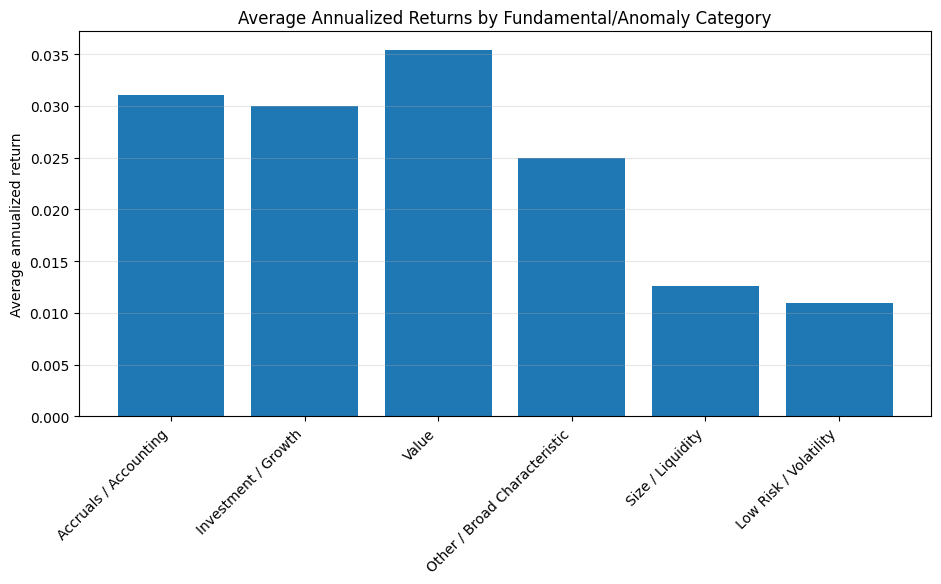

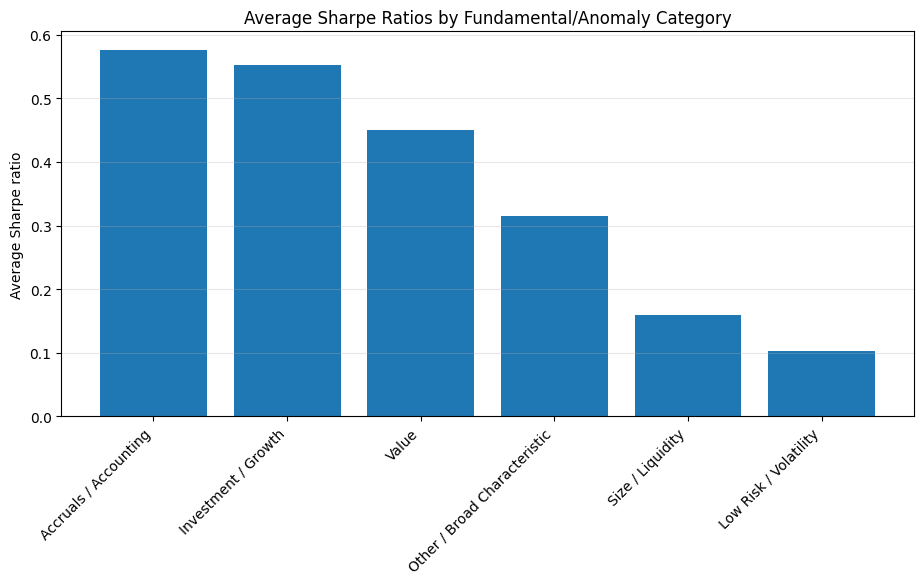

In [14]:
# Plot category-level average returns and Sharpe ratios.

if not jkp_factors.empty:
    plt.figure(figsize=(11, 5))
    plt.bar(group_summary.index, group_summary["Mean Ann. Return"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Average annualized return")
    plt.title("Average Annualized Returns by Fundamental/Anomaly Category")
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()

    plt.figure(figsize=(11, 5))
    plt.bar(group_summary.index, group_summary["Sharpe Ratio"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Average Sharpe ratio")
    plt.title("Average Sharpe Ratios by Fundamental/Anomaly Category")
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()

## 10.3 Fundamental Analysis Versus Fundamental Factor Investing

Fundamental analysis usually studies one firm at a time.

Factor investing studies whether a characteristic predicts average returns across many firms.

These are related but not identical.

A fundamental analyst may ask:

> Is this firm undervalued relative to its future cash flows?

A factor investor may ask:

> Do firms with this characteristic earn higher average returns as a group?

A signal can appear in factor data even if individual security selection remains difficult. Conversely, a skilled analyst may find firm-specific information not captured by broad factor portfolios.

Representative factors by category:


,Teaching Category,Mean Ann. Return,Sharpe Ratio,Max Drawdown
Factor,,,,
cop_at,Other / Broad Characteristic,0.0608,1.0523,-0.1194
oaccruals_ni,Accruals / Accounting,0.0407,0.8251,-0.1405
rmax5_rvol_21d,Low Risk / Volatility,0.0491,0.6639,-0.4645
ocf_at,Value,0.0508,0.6573,-0.2454
qmj_growth,Investment / Growth,0.0300,0.5529,-0.1982
at_turnover,Size / Liquidity,0.0279,0.3684,-0.3029


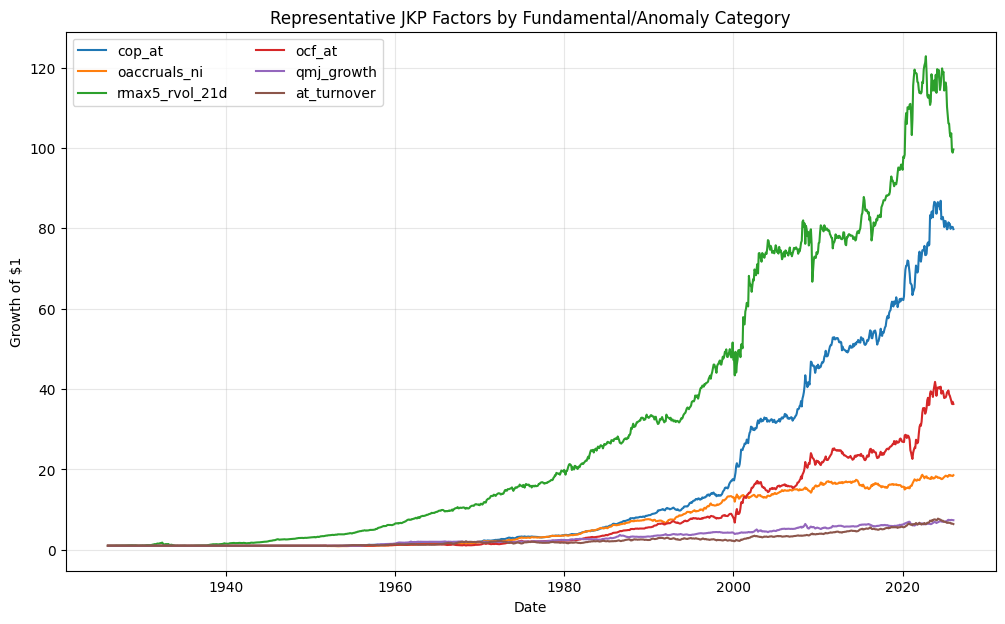

In [15]:
# Example: plot cumulative returns of factors grouped by category.
# If many factors are present, plot one representative top-Sharpe factor from each category.

if not jkp_factors.empty:
    representative = (
        category_summary
        .dropna(subset=["Sharpe Ratio"])
        .sort_values("Sharpe Ratio", ascending=False)
        .groupby("Teaching Category")
        .head(1)
        .index
        .tolist()
    )

    print("Representative factors by category:")
    display(category_summary.loc[representative][["Teaching Category", "Mean Ann. Return", "Sharpe Ratio", "Max Drawdown"]])

    rep_wealth = (1 + jkp_factors[representative].fillna(0)).cumprod()

    plt.figure(figsize=(12, 7))
    for col in rep_wealth.columns:
        plt.plot(rep_wealth.index, rep_wealth[col], label=col)
    plt.xlabel("Date")
    plt.ylabel("Growth of $1")
    plt.title("Representative JKP Factors by Fundamental/Anomaly Category")
    plt.legend(ncol=2)
    plt.grid(True, alpha=0.3)
    plt.show()

# 11. Semi-Strong Tests and the Joint Hypothesis Problem

If a value strategy earns high average returns, there are at least two interpretations:

1. value stocks were mispriced;
2. value stocks were riskier in ways the model did not capture.

So rejecting zero alpha does not automatically prove inefficiency. It may instead reveal a bad benchmark model.

# 12. Market Anomalies

Important anomalies include P/E effects, size, book-to-market or value, momentum, post-earnings announcement drift, low volatility, accruals, growth, profitability, investment, and q-factor effects. Some anomalies weaken after publication. Some survive. Some become risk factors in multifactor models.

In [16]:
def annualized_summary(factors, periods_per_year=12):
    out=pd.DataFrame(index=factors.columns)
    out['Mean Ann. Return']=factors.mean()*periods_per_year
    out['Ann. Volatility']=factors.std(ddof=1)*np.sqrt(periods_per_year)
    out['Sharpe Ratio']=out['Mean Ann. Return']/out['Ann. Volatility']
    out['Skewness']=factors.skew()
    out['Excess Kurtosis']=factors.kurtosis()
    out['Worst Month']=factors.min()
    out['Best Month']=factors.max()
    out['Observations']=factors.count()
    return out.sort_values('Sharpe Ratio', ascending=False)

def drawdown_from_returns(r):
    wealth=(1+r.fillna(0)).cumprod()
    return wealth/wealth.cummax()-1

if not jkp_factors.empty:
    jkp_summary=annualized_summary(jkp_factors)
    jkp_drawdowns=jkp_factors.apply(drawdown_from_returns)
    jkp_summary['Max Drawdown']=jkp_drawdowns.min()
    display(jkp_summary)

,Mean Ann. Return,Ann. Volatility,Sharpe Ratio,Skewness,Excess Kurtosis,Worst Month,Best Month,Observations,Max Drawdown
name,,,,,,,,,
cop_at,0.0608,0.0578,1.0523,0.6473,3.3839,-0.0531,0.0957,890,-0.1194
noa_at,0.0520,0.0552,0.9430,0.2785,2.9521,-0.0639,0.1049,890,-0.2839
resff3_12_1,0.0684,0.0758,0.9019,-0.3492,6.3441,-0.1603,0.1170,872,-0.3340
nfna_gr1a,0.0297,0.0349,0.8524,0.0077,2.0610,-0.0436,0.0494,890,-0.1886
fnl_gr1a,0.0299,0.0355,0.8419,-0.0029,1.8307,-0.0436,0.0472,890,-0.2583
...,...,...,...,...,...,...,...,...,...
sti_gr1a,-0.0059,0.0468,-0.1265,0.1945,9.6158,-0.0730,0.0901,719,-0.5136
at_be,-0.0128,0.0988,-0.1297,0.7385,23.1851,-0.1992,0.3030,902,-0.8172
kz_index,-0.0093,0.0680,-0.1370,0.2044,2.9581,-0.0829,0.1154,890,-0.6519


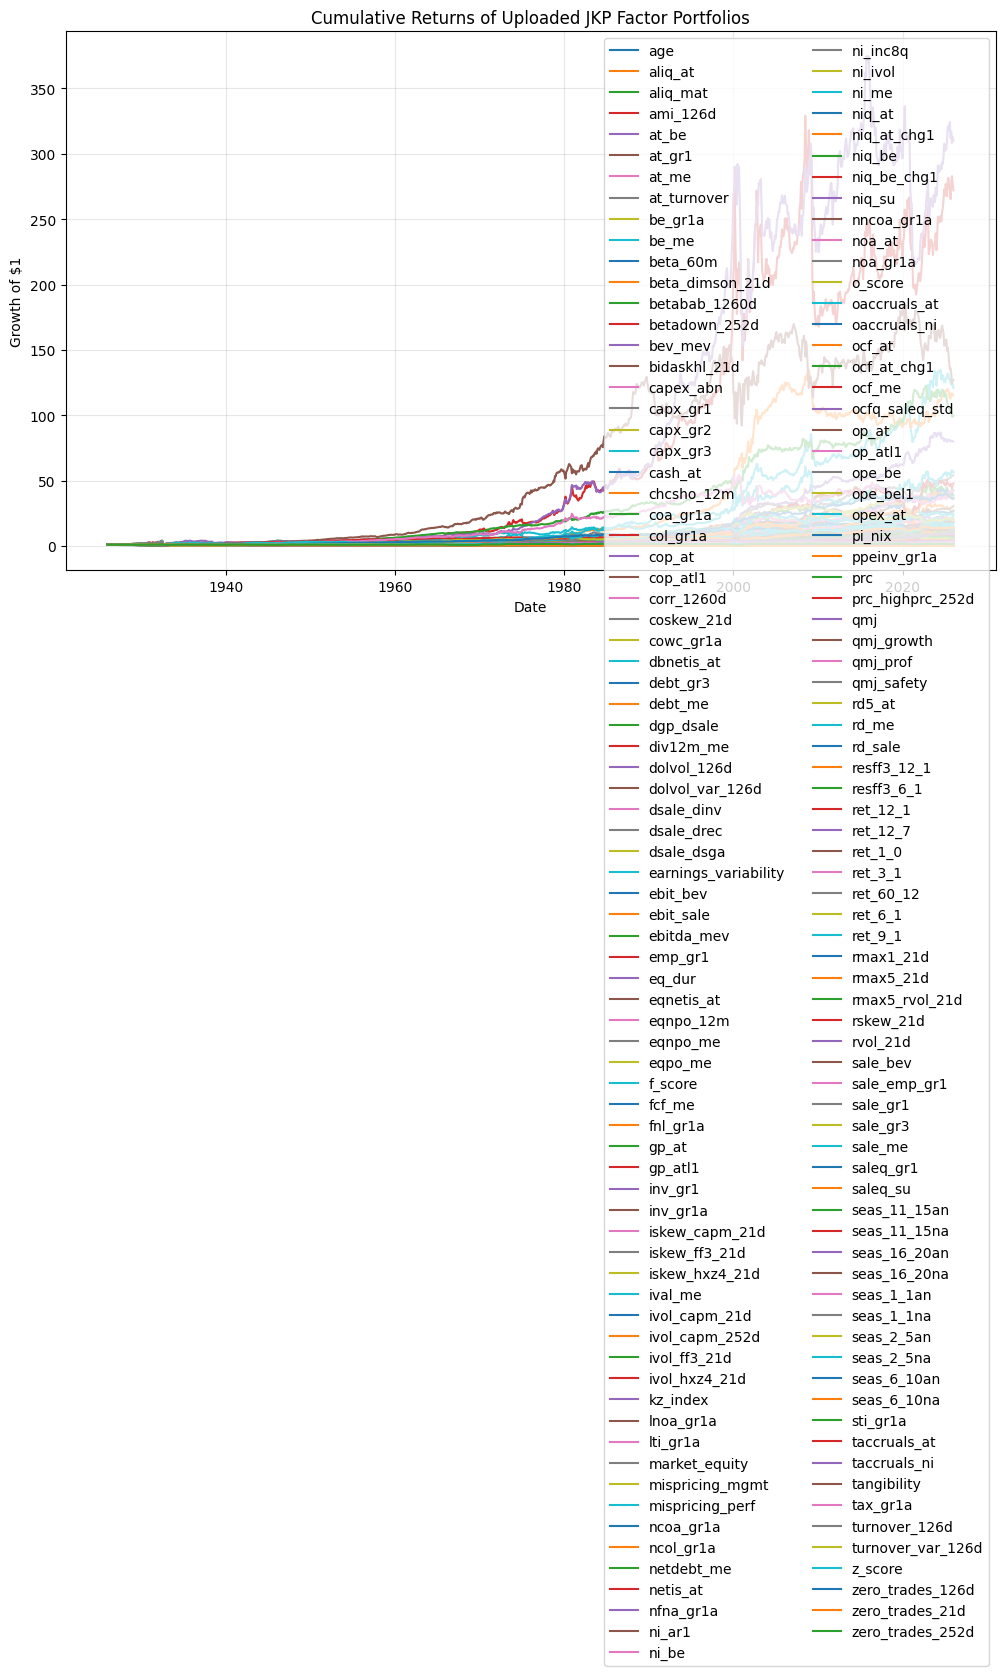

name,age,aliq_at,aliq_mat,ami_126d,at_be,at_gr1,at_me,at_turnover,be_gr1a,be_me,beta_60m,beta_dimson_21d,betabab_1260d,betadown_252d,bev_mev,bidaskhl_21d,capex_abn,capx_gr1,capx_gr2,capx_gr3,cash_at,chcsho_12m,coa_gr1a,col_gr1a,cop_at,cop_atl1,corr_1260d,coskew_21d,cowc_gr1a,dbnetis_at,debt_gr3,debt_me,dgp_dsale,div12m_me,dolvol_126d,dolvol_var_126d,dsale_dinv,dsale_drec,dsale_dsga,earnings_variability,...,ret_12_1,ret_12_7,ret_1_0,ret_3_1,ret_60_12,ret_6_1,ret_9_1,rmax1_21d,rmax5_21d,rmax5_rvol_21d,rskew_21d,rvol_21d,sale_bev,sale_emp_gr1,sale_gr1,sale_gr3,sale_me,saleq_gr1,saleq_su,seas_11_15an,seas_11_15na,seas_16_20an,seas_16_20na,seas_1_1an,seas_1_1na,seas_2_5an,seas_2_5na,seas_6_10an,seas_6_10na,sti_gr1a,taccruals_at,taccruals_ni,tangibility,tax_gr1a,turnover_126d,turnover_var_126d,z_score,zero_trades_126d,zero_trades_21d,zero_trades_252d
name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
age,1.0000,-0.8586,0.4359,0.3142,0.6914,-0.7660,-0.6942,0.0847,-0.6497,-0.6307,-0.4481,-0.3802,-0.3819,-0.5226,-0.6766,0.6622,0.2113,-0.6424,-0.6386,-0.6406,0.8382,-0.7070,-0.6806,-0.7363,-0.1281,0.2816,0.0337,0.0003,-0.0829,-0.2416,-0.2538,-0.7376,0.1459,-0.6835,0.0969,-0.4840,0.1681,-0.0668,0.3223,-0.4631,...,0.1808,0.2227,0.0511,0.0586,-0.1422,0.1024,0.1460,-0.6228,-0.6020,-0.0396,-0.3310,-0.6194,0.4103,0.3040,-0.7589,-0.7278,-0.6185,-0.7460,0.4368,0.0819,0.0064,0.0100,-0.0648,0.1739,0.2624,0.0772,-0.4275,0.1296,-0.4326,0.0562,0.1662,-0.2669,0.4418,0.3616,-0.5367,-0.3977,0.7079,-0.5414,-0.5090,-0.5216
aliq_at,-0.8586,1.0000,-0.5102,-0.2330,-0.7188,0.9003,0.7437,-0.2558,0.8095,0.6958,0.6785,0.6477,0.6531,0.7680,0.7339,-0.7263,-0.0555,0.7648,0.7280,0.7315,-0.8356,0.7970,0.8517,0.8678,0.0231,-0.4065,0.2318,0.0562,0.2547,0.2035,0.2528,0.7906,-0.2604,0.8586,0.1576,0.3277,-0.1443,-0.0171,-0.3979,0.3957,...,-0.1740,-0.2590,-0.1391,-0.0023,0.3771,-0.0654,-0.1146,0.7900,0.7882,0.1361,0.4275,0.7941,-0.5392,-0.3428,0.8482,0.8097,0.6065,0.8165,-0.5228,-0.0754,-0.0132,-0.0040,0.1326,-0.2206,-0.2400,-0.1909,0.6835,-0.1626,0.5340,-0.1170,0.0172,0.3553,-0.4352,-0.5540,0.7534,0.2315,-0.8346,0.7543,0.7288,0.7561
aliq_mat,0.4359,-0.5102,1.0000,-0.2096,0.5633,-0.5507,-0.7256,0.1619,-0.5938,-0.7193,-0.1609,-0.2259,-0.1829,-0.2838,-0.7413,0.1901,-0.0609,-0.4641,-0.4820,-0.4768,0.5820,-0.4286,-0.4800,-0.5107,0.3219,0.5328,-0.1962,-0.0207,-0.0738,-0.2587,-0.1559,-0.7102,0.1796,-0.5552,-0.3909,-0.0240,-0.0126,0.0268,0.2037,-0.0989,...,0.0758,0.0755,-0.0064,0.0425,-0.5880,0.0469,0.0729,-0.2637,-0.2570,-0.0356,-0.1556,-0.2520,0.3330,0.1127,-0.5038,-0.5375,-0.6765,-0.5005,0.3824,0.0401,-0.0131,-0.0293,-0.1060,0.0264,0.1180,0.1936,-0.6151,0.1658,-0.4667,0.1144,-0.1824,-0.3639,0.1453,0.3724,-0.2171,0.0280,0.7425,-0.2557,-0.2008,-0.2736
ami_126d,0.3142,-0.2330,-0.2096,1.0000,0.1830,-0.0675,0.0021,0.0881,-0.0017,0.0862,-0.4722,-0.3887,-0.4519,-0.3302,0.0485,0.6746,0.2285,-0.0696,-0.0682,-0.0683,0.2174,-0.1850,-0.1271,-0.0915,-0.3149,-0.2187,0.0887,-0.0637,-0.1214,0.0205,0.0150,-0.0605,-0.1776,-0.4235,0.6967,-0.4982,0.0141,-0.0743,-0.0248,-0.2545,...,-0.3227,-0.1697,-0.0302,-0.2344,0.5578,-0.3357,-0.3124,-0.5404,-0.5529,-0.0935,-0.2217,-0.5508,0.2081,-0.0454,-0.0939,-0.0828,0.0779,-0.0839,-0.0699,-0.0200,0.0200,0.0534,0.0217,-0.1954,-0.1315,-0.1669,0.2679,-0.0246,-0.0427,-0.0448,0.1406,-0.0612,0.1244,-0.0913,-0.1531,-0.4214,0.0870,-0.0632,-0.0760,-0.0546
at_be,0.6914,-0.7188,0.5633,0.1830,1.0000,-0.6508,-0.8166,0.1601,-0.7280,-0.6381,-0.5136,-0.4585,-0.4638,-0.5762,-0.7231,0.6207,0.0960,-0.5906,-0.5785,-0.5815,0.7718,-0.6759,-0.5300,-0.6291,0.1986,0.5469,-0.1319,-0.0296,0.0149,-0.1094,-0.0121,-0.8605,0.1609,-0.7246,-0.1667,-0.3266,0.1061,-0.0189,0.2834,-0.4720,...,0.2154,0.2381,-0.0040,0.0831,-0.2581,0.1433,0.1789,-0.6576,-0.6563,-0.1435,-0.3950,-0.6447,0.3503,0.2239,-0.6359,-0.5682,-0.6954,-0.6697,0.4488,0.0750,0.1047,-0.0410,-0.0019,0.1458,0.2964,0.1472,-0.5456,0.2128,-0.5318,0.0929,0.1280,-0.2793,0.6157,0.3878,-0.5788,-0.2131,0.

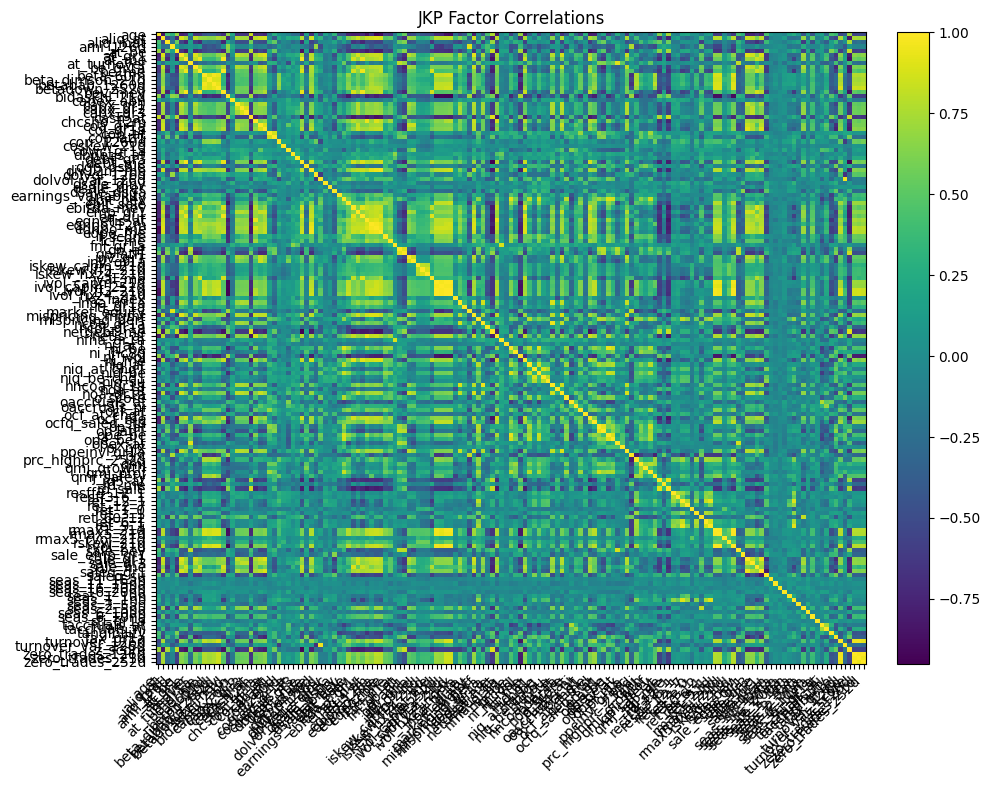

In [17]:
if not jkp_factors.empty:
    wealth=(1+jkp_factors.fillna(0)).cumprod()
    plt.figure(figsize=(12,7))
    for col in wealth.columns:
        plt.plot(wealth.index, wealth[col], label=col)
    plt.xlabel('Date'); plt.ylabel('Growth of $1')
    plt.title('Cumulative Returns of Uploaded JKP Factor Portfolios')
    plt.legend(ncol=2); plt.grid(True, alpha=0.3); plt.show()

    corr=jkp_factors.corr()
    display(corr)
    plt.figure(figsize=(10,8))
    im=plt.imshow(corr, aspect='auto')
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
    plt.yticks(range(len(corr.index)), corr.index)
    plt.title('JKP Factor Correlations')
    plt.tight_layout(); plt.show()

# 13. Active Versus Passive Management

Passive management tries to capture broad market returns at low cost. Active management tries to outperform through security selection, timing, sector rotation, factor tilts, risk management, tax management, or liquidity provision.

In an efficient market, average active management before fees is approximately zero-sum relative to the market portfolio. After fees and transaction costs, average active management is negative-sum. This does not imply no one can outperform; it implies persistent outperformance is difficult to identify ex ante.

# 14. Portfolio Management in an Efficient Market

Even if markets are efficient, investors differ in risk aversion, horizons, tax status, labor income risk, liquidity needs, liabilities, constraints, and institutional mandates. Portfolio management remains valuable through diversification, asset allocation, rebalancing, tax efficiency, liquidity planning, liability matching, cost control, and behavioral discipline.

# 15. Event Studies

An event study measures how prices respond to a specific event. The abnormal return is:

$$
AR_{i,t}=R_{i,t}-E[R_{i,t}].
$$

Common benchmarks include:

$$
AR_{i,t}=R_{i,t}-R_{M,t}
$$

for a market benchmark,

$$
AR_{i,t}=R_{i,t}-R_{Industry,t}
$$

for an industry benchmark, and

$$
AR_{i,t}=R_{i,t}-(\hat{\alpha}_i+\hat{\beta}_iR_{M,t})
$$

for a market model. The cumulative abnormal return is:

$$
CAR_i(T_1,T_2)=\sum_{t=T_1}^{T_2}AR_{i,t}.
$$

In [18]:
np.random.seed(1234)
n_days=260; event_day=200
market=np.random.normal(0.0004,0.012,n_days)
industry=0.0002+0.8*market+np.random.normal(0,0.006,n_days)
stock=0.0001+1.2*market+np.random.normal(0,0.018,n_days)
event_effect=np.zeros(n_days)
event_effect[event_day-3:event_day]=[0.01,0.015,0.02]
event_effect[event_day]=0.08
event_effect[event_day+1:event_day+4]=[0.01,0.004,-0.002]
stock_event=stock+event_effect

dates=pd.date_range('2025-01-01', periods=n_days, freq='B')
event_df=pd.DataFrame({'Stock':stock_event,'Market':market,'Industry':industry}, index=dates)
estimation=event_df.iloc[:event_day-20]
window=event_df.iloc[event_day-10:event_day+11].copy()
X=np.column_stack([np.ones(len(estimation)), estimation['Market'].values])
y=estimation['Stock'].values
alpha_hat,beta_hat=np.linalg.inv(X.T@X)@X.T@y
window['AR_market_benchmark']=window['Stock']-window['Market']
window['AR_industry_benchmark']=window['Stock']-window['Industry']
window['AR_market_model']=window['Stock']-(alpha_hat+beta_hat*window['Market'])
window['t']=np.arange(-10,11)
for col in ['AR_market_benchmark','AR_industry_benchmark','AR_market_model']:
    window['CAR_'+col.replace('AR_','')]=window[col].cumsum()
print(f'Estimated alpha: {alpha_hat:.5f}')
print(f'Estimated beta: {beta_hat:.3f}')
display(window.head())

Estimated alpha: 0.00092
Estimated beta: 1.245


,Stock,Market,Industry,AR_market_benchmark,AR_industry_benchmark,AR_market_model,t,CAR_market_benchmark,CAR_industry_benchmark,CAR_market_model
2025-09-24,0.0298,0.0029,-0.0079,0.0269,0.0377,0.0252,-10,0.0269,0.0377,0.0252
2025-09-25,0.0047,-0.0067,-0.0035,0.0114,0.0083,0.0122,-9,0.0383,0.0459,0.0374
2025-09-26,0.0058,-0.0173,-0.0130,0.0230,0.0188,0.0263,-8,0.0613,0.0647,0.0637
2025-09-29,-0.0060,-0.0104,-0.0103,0.0044,0.0043,0.0060,-7,0.0657,0.0690,0.0697
2025-09-30,-0.0031,0.0137,0.0076,-0.0167,-0.0106,-0.0210,-6,0.0490,0.0584,0.0488


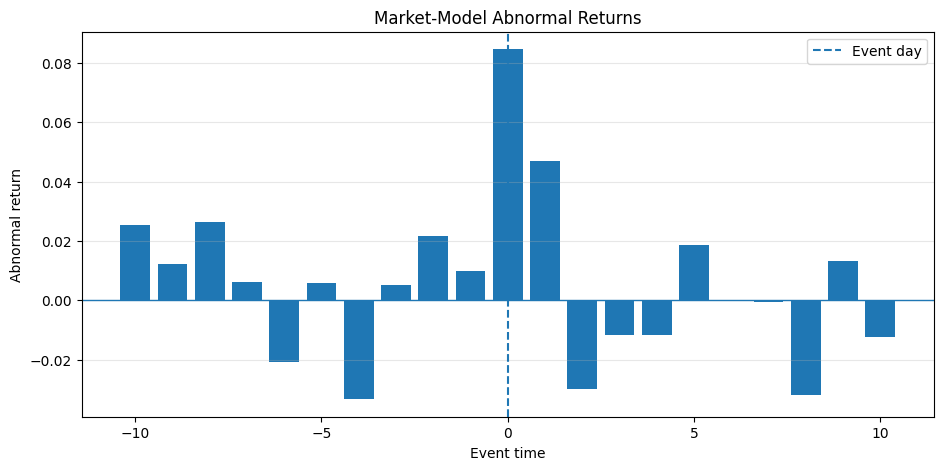

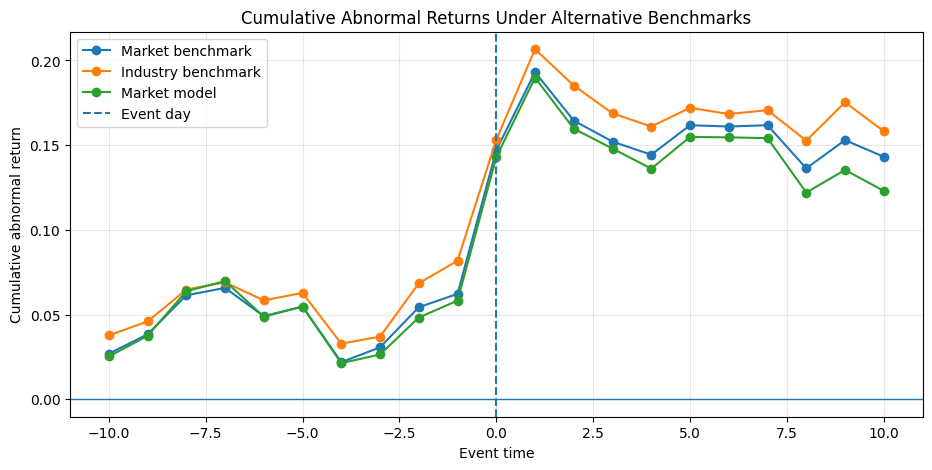

In [19]:
plt.figure(figsize=(11,5))
plt.bar(window['t'], window['AR_market_model'])
plt.axvline(0, linestyle='--', label='Event day')
plt.axhline(0, linewidth=1)
plt.xlabel('Event time'); plt.ylabel('Abnormal return')
plt.title('Market-Model Abnormal Returns')
plt.legend(); plt.grid(True, axis='y', alpha=0.3); plt.show()

plt.figure(figsize=(11,5))
plt.plot(window['t'], window['CAR_market_benchmark'], marker='o', label='Market benchmark')
plt.plot(window['t'], window['CAR_industry_benchmark'], marker='o', label='Industry benchmark')
plt.plot(window['t'], window['CAR_market_model'], marker='o', label='Market model')
plt.axvline(0, linestyle='--', label='Event day')
plt.axhline(0, linewidth=1)
plt.xlabel('Event time'); plt.ylabel('Cumulative abnormal return')
plt.title('Cumulative Abnormal Returns Under Alternative Benchmarks')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

## Information Leakage

If abnormal returns appear before the official event date, possible explanations include information leakage, rumors, anticipatory trading, gradual information diffusion, confounding events, or misidentification of the true event date.

# 16. Synthetic Control Event Studies

A synthetic control uses a weighted combination of comparable securities to approximate the treated security before the event. If:

$$
R_{0,t}\approx \sum_j w_j R_{j,t}
$$

before the event, then after the event:

$$
AR_t=R_{0,t}-\sum_j w_jR_{j,t}.
$$

Synthetic controls are useful when market and industry benchmarks are too crude.

,Peer,Synthetic Control Weight
0,Peer_1,0.3007
1,Peer_2,0.1203
2,Peer_3,0.2129
3,Peer_4,0.1715
4,Peer_5,0.2016
5,Peer_6,0.1068


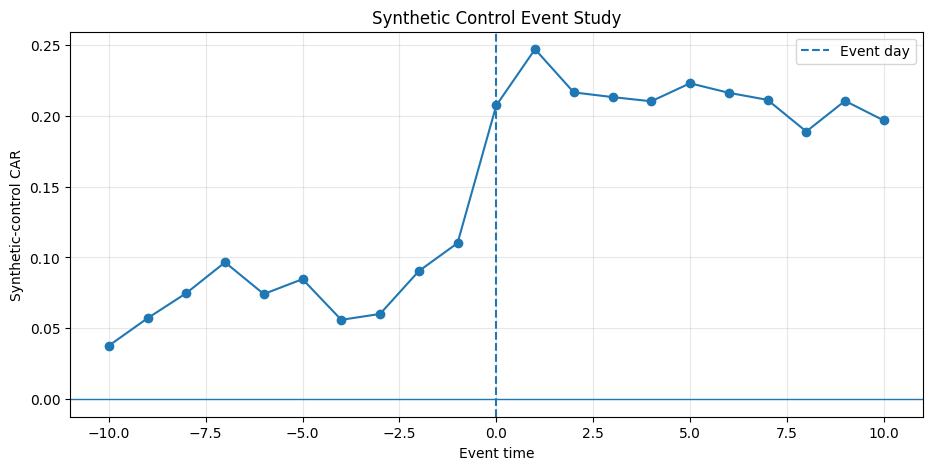

In [20]:
np.random.seed(4321)
peers=pd.DataFrame({f'Peer_{j}':0.5*market+0.4*industry+np.random.normal(0,0.015,n_days) for j in range(1,7)}, index=dates)
pre_idx=np.arange(0,event_day-20)
weights_sc=np.linalg.lstsq(peers.iloc[pre_idx].values, stock_event[pre_idx], rcond=None)[0]
synthetic_return=peers.values@weights_sc
synthetic_window=pd.DataFrame({'Treated':stock_event,'Synthetic':synthetic_return}, index=dates).iloc[event_day-10:event_day+11].copy()
synthetic_window['AR_synthetic']=synthetic_window['Treated']-synthetic_window['Synthetic']
synthetic_window['CAR_synthetic']=synthetic_window['AR_synthetic'].cumsum()
synthetic_window['t']=np.arange(-10,11)
display(pd.DataFrame({'Peer':peers.columns, 'Synthetic Control Weight':weights_sc}))

plt.figure(figsize=(11,5))
plt.plot(synthetic_window['t'], synthetic_window['CAR_synthetic'], marker='o')
plt.axvline(0, linestyle='--', label='Event day')
plt.axhline(0, linewidth=1)
plt.xlabel('Event time'); plt.ylabel('Synthetic-control CAR')
plt.title('Synthetic Control Event Study')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

# 17. Problems in Testing Market Efficiency

Tests of market efficiency face several problems:

- **Magnitude:** even statistically significant abnormal returns may be too small after costs and taxes.
- **Selection bias:** successful anomalies are more visible than failed searches.
- **Lucky events:** with many managers and strategies, some will look exceptional by chance.
- **Data mining:** many tested rules produce some false discoveries.
- **Model dependence:** abnormal returns require a model of expected returns.

The last point is the joint hypothesis problem: a test of efficiency is also a test of the asset-pricing model used to measure expected returns.

# 18. Strong-Form Tests

Strong-form efficiency says prices reflect all information, including private information. Evidence against literal strong-form efficiency includes profitable insider trading, informed trading before announcements, and information advantages among some institutions. Strong-form tests are difficult because private information is hard to observe, illegal trading is hidden, and apparent skill can reflect luck or risk exposure.

# 19. Analysts and Mutual Fund Managers

If markets are highly efficient, most analysts and active managers should not persistently outperform after fees and risk adjustment. Common empirical findings include weak average after-fee active mutual fund performance, limited persistence, and substantial importance of costs, turnover, and benchmark choice. Analyst work may still improve price discovery, monitoring, risk identification, and corporate governance even if average stock-picking alpha is difficult.

## 19.1 Simulation: Short-Run Outperformance and Weak Persistence

A central problem in evaluating mutual funds is separating skill from luck.

Even if no manager has true skill, some funds will outperform over short periods.

With many funds, the best performers in a three-year window can look impressive purely by chance.

The key empirical question is whether outperformance persists.

If performance is mostly luck, then the top funds in one period should not reliably remain top funds in the next period.

In [21]:
# Mutual fund performance simulation: many managers, no skill.

np.random.seed(2030)

n_funds = 500
months = 120
period = 36

market_mu = 0.006
market_sigma = 0.04
fund_resid_sigma = 0.035
expense_ratio_monthly = 0.01 / 12

market_returns = np.random.normal(market_mu, market_sigma, months)

# All funds have beta 1 and true alpha 0 before fees.
fund_returns = pd.DataFrame(
    {
        f"Fund_{i+1:03d}": market_returns + np.random.normal(0, fund_resid_sigma, months) - expense_ratio_monthly
        for i in range(n_funds)
    }
)

fund_returns.index = pd.date_range("2015-01-31", periods=months, freq="M")

# Split into two non-overlapping 36-month periods.
first = fund_returns.iloc[:period]
second = fund_returns.iloc[period:2*period]

first_cum = (1 + first).prod() - 1
second_cum = (1 + second).prod() - 1

performance = pd.DataFrame({
    "First 36-Month Return": first_cum,
    "Second 36-Month Return": second_cum
})

performance["First-Period Rank"] = performance["First 36-Month Return"].rank(ascending=False)
performance["Second-Period Rank"] = performance["Second 36-Month Return"].rank(ascending=False)

top_decile_cutoff = int(0.10 * n_funds)
top_first = performance.nsmallest(top_decile_cutoff, "First-Period Rank").index
top_second = performance.nsmallest(top_decile_cutoff, "Second-Period Rank").index

persistence_count = len(set(top_first).intersection(set(top_second)))
persistence_rate = persistence_count / top_decile_cutoff

print(f"Funds simulated: {n_funds}")
print(f"Top-decile funds in each period: {top_decile_cutoff}")
print(f"Number of first-period top-decile funds also top-decile in second period: {persistence_count}")
print(f"Persistence rate among first-period winners: {persistence_rate:.2%}")
display(performance.sort_values("First-Period Rank").head(10))

Funds simulated: 500
Top-decile funds in each period: 50
Number of first-period top-decile funds also top-decile in second period: 6
Persistence rate among first-period winners: 12.00%


/tmp/ipykernel_7316/3610202890.py:24: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  fund_returns.index = pd.date_range("2015-01-31", periods=months, freq="M")


,First 36-Month Return,Second 36-Month Return,First-Period Rank,Second-Period Rank
Fund_148,0.4965,0.7504,1.0000,136.0000
Fund_281,0.4904,1.0597,2.0000,43.0000
Fund_474,0.4438,0.1120,3.0000,463.0000
Fund_009,0.4389,0.6220,4.0000,201.0000
Fund_197,0.4344,0.0443,5.0000,483.0000
Fund_202,0.4331,0.8937,6.0000,88.0000
Fund_387,0.4143,0.3639,7.0000,341.0000
Fund_184,0.3964,0.7271,8.0000,151.0000
Fund_221,0.3920,0.3239,9.0000,374.0000
Fund_006,0.3633,0.6010,10.0000,211.0000


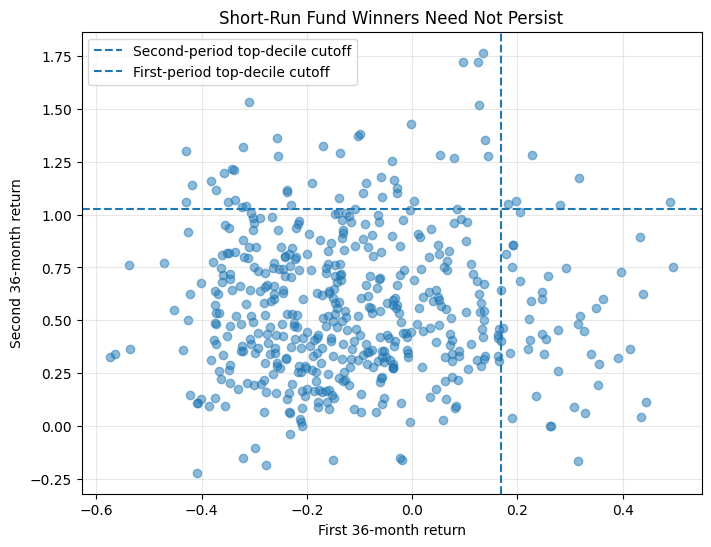

Rank correlation between first and second periods: -0.0094


In [22]:
# Visualize weak persistence.

plt.figure(figsize=(8, 6))
plt.scatter(performance["First 36-Month Return"], performance["Second 36-Month Return"], alpha=0.5)
plt.axhline(performance["Second 36-Month Return"].quantile(0.90), linestyle="--", label="Second-period top-decile cutoff")
plt.axvline(performance["First 36-Month Return"].quantile(0.90), linestyle="--", label="First-period top-decile cutoff")
plt.xlabel("First 36-month return")
plt.ylabel("Second 36-month return")
plt.title("Short-Run Fund Winners Need Not Persist")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

rank_corr = performance[["First-Period Rank", "Second-Period Rank"]].corr().iloc[0, 1]
print(f"Rank correlation between first and second periods: {rank_corr:.4f}")

The scatter plot shows that short-run winners are not necessarily future winners.

This is the mutual fund version of the lucky-events problem.

A manager can outperform over a short horizon because of favorable residual shocks, sector exposure, style exposure, or benchmark mismatch.

Persistent outperformance is harder to demonstrate.

## 19.2 Simulation with a Small Amount of True Skill

Now suppose a small fraction of funds have genuine positive alpha.

Even then, identifying them is difficult because realized returns mix skill and noise.

The next simulation gives 5% of funds a positive monthly alpha, then asks whether the top historical performers are actually skilled.

In [23]:
# Mutual fund simulation with rare skill.

np.random.seed(2031)

n_funds = 500
months = 120
skilled_share = 0.05
n_skilled = int(n_funds * skilled_share)

true_alpha = np.zeros(n_funds)
true_alpha[:n_skilled] = 0.002  # 20 bps per month before fees
np.random.shuffle(true_alpha)

market_returns = np.random.normal(market_mu, market_sigma, months)

fund_returns_skill = pd.DataFrame(
    market_returns[:, None] + true_alpha[None, :] + np.random.normal(0, fund_resid_sigma, (months, n_funds)) - expense_ratio_monthly,
    columns=[f"Fund_{i+1:03d}" for i in range(n_funds)]
)

full_cum = (1 + fund_returns_skill).prod() - 1
full_rank = full_cum.rank(ascending=False)

skill_df = pd.DataFrame({
    "True Monthly Alpha": true_alpha,
    "Full-Sample Return": full_cum.values,
    "Full-Sample Rank": full_rank.values
}, index=fund_returns_skill.columns)

top_25 = skill_df.nsmallest(25, "Full-Sample Rank")
skilled_in_top_25 = (top_25["True Monthly Alpha"] > 0).sum()

print(f"True skilled funds: {n_skilled}")
print(f"Skilled funds among top 25 realized performers: {skilled_in_top_25}")
display(top_25)

True skilled funds: 25
Skilled funds among top 25 realized performers: 4


,True Monthly Alpha,Full-Sample Return,Full-Sample Rank
Fund_173,0.0000,2.9964,1.0000
Fund_015,0.0000,2.8996,2.0000
Fund_148,0.0020,2.6745,3.0000
Fund_096,0.0000,2.3743,4.0000
Fund_171,0.0000,2.3353,5.0000
Fund_345,0.0000,2.2839,6.0000
Fund_264,0.0000,2.1290,7.0000
Fund_298,0.0000,2.0895,8.0000
Fund_279,0.0020,2.0306,9.0000
Fund_358,0.0000,2.0302,10.0000


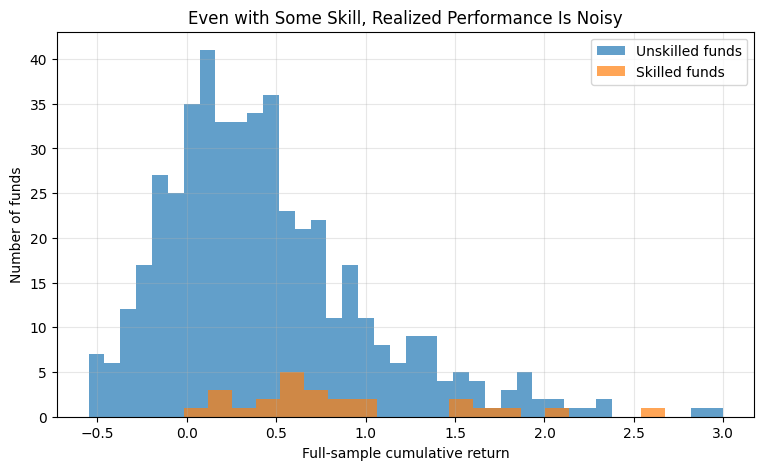

In [24]:
plt.figure(figsize=(9, 5))
plt.hist(skill_df.loc[skill_df["True Monthly Alpha"] == 0, "Full-Sample Return"], bins=40, alpha=0.7, label="Unskilled funds")
plt.hist(skill_df.loc[skill_df["True Monthly Alpha"] > 0, "Full-Sample Return"], bins=20, alpha=0.7, label="Skilled funds")
plt.xlabel("Full-sample cumulative return")
plt.ylabel("Number of funds")
plt.title("Even with Some Skill, Realized Performance Is Noisy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

This simulation shows why fund evaluation is statistically hard.

Even when skill exists, some unskilled funds will look excellent, and some skilled funds will look ordinary.

A serious performance evaluation should use:

- risk-adjusted alpha,
- factor models,
- fees and expenses,
- persistence tests,
- out-of-sample performance,
- holdings-based analysis,
- style consistency,
- capacity and transaction-cost analysis.

# 20. Interpretations of Anomalies

Anomalies may reflect risk premia, behavioral mispricing, limits to arbitrage, data mining, market microstructure, or institutional frictions. The question is not merely whether a pattern exists. The question is whether it survives out of sample, after costs, across markets, and under a plausible economic explanation.

# 21. Final Takeaways

1. Efficient prices often behave like random walks because news is unpredictable.
2. Weak-form efficiency concerns past prices and trading data.
3. Semi-strong efficiency concerns public information.
4. Strong-form efficiency concerns private information.
5. Technical rules require serious out-of-sample and transaction-cost testing.
6. Fundamental analysis adds value only if it produces information or interpretation not already in prices.
7. Event studies measure abnormal returns around information events.
8. Information leakage appears as abnormal returns before the event.
9. Market anomalies can reflect risk, mispricing, institutions, frictions, or data mining.
10. The joint hypothesis problem makes tests of efficiency inseparable from tests of asset-pricing models.
11. Portfolio management remains important even in efficient markets because investors differ in taxes, risks, horizons, constraints, and liabilities.